# Lab 4: EDA with Data Visualization

**Goal:** Explore relationships in the wrangled dataset (`dataset_part_2.csv`) using charts, to understand what drives a successful landing before we build a predictive model. This notebook produces every chart your report's EDA slide (1.11) needs: scatter plots, bar charts, and a yearly success trend.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
%matplotlib inline

## 0. Load the wrangled dataset
Upload `dataset_part_2.csv` (from Lab 3) into this Colab session, or the fallback below will fetch a working copy so you're never blocked.

In [2]:
if os.path.exists('dataset_part_2.csv'):
    df = pd.read_csv('dataset_part_2.csv')
else:
    print('dataset_part_2.csv not found locally, loading from IBM dataset repository...')
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
    df = pd.read_csv(fallback_url)

df.head()

dataset_part_2.csv not found locally, loading from IBM dataset repository...


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 1. Flight Number vs. Payload Mass, colored by outcome
Do later flights (more experience) and heavier payloads affect landing success?

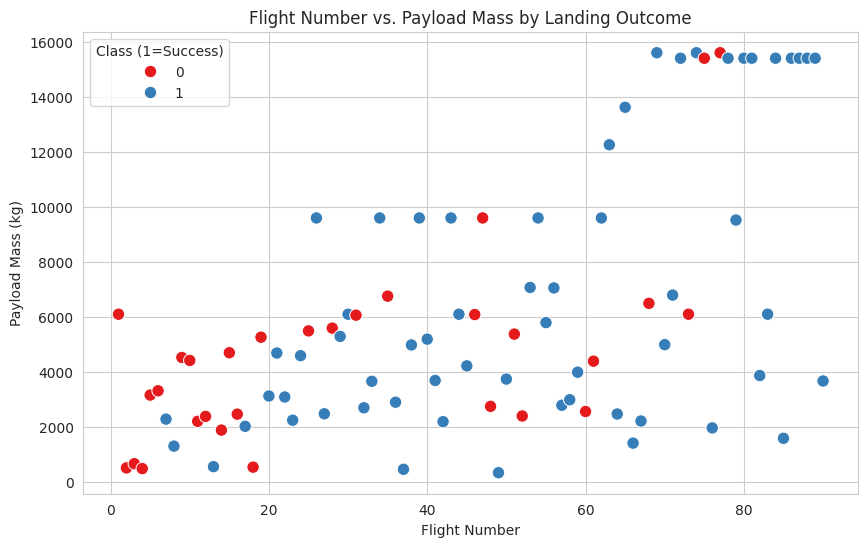

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='PayloadMass', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Payload Mass (kg)')
plt.title('Flight Number vs. Payload Mass by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 2. Flight Number vs. Launch Site

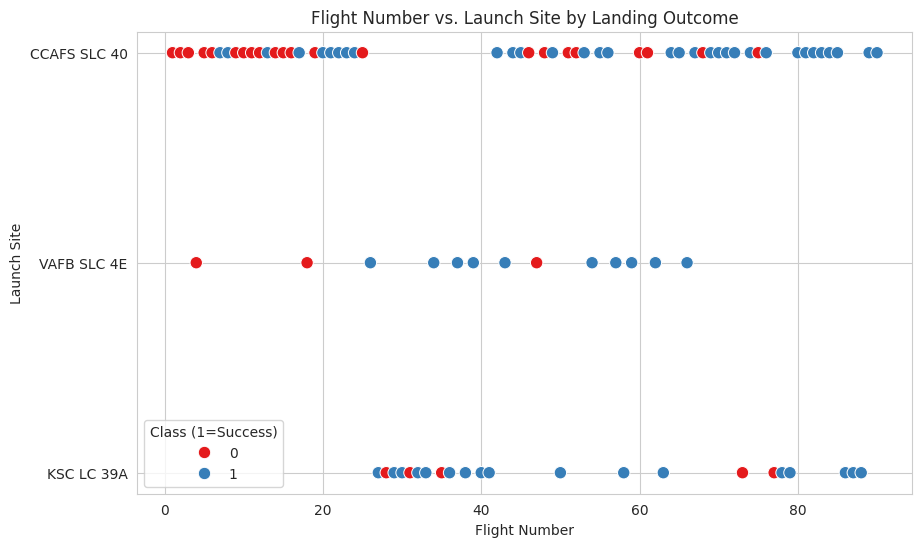

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight Number vs. Launch Site by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 3. Payload Mass vs. Launch Site

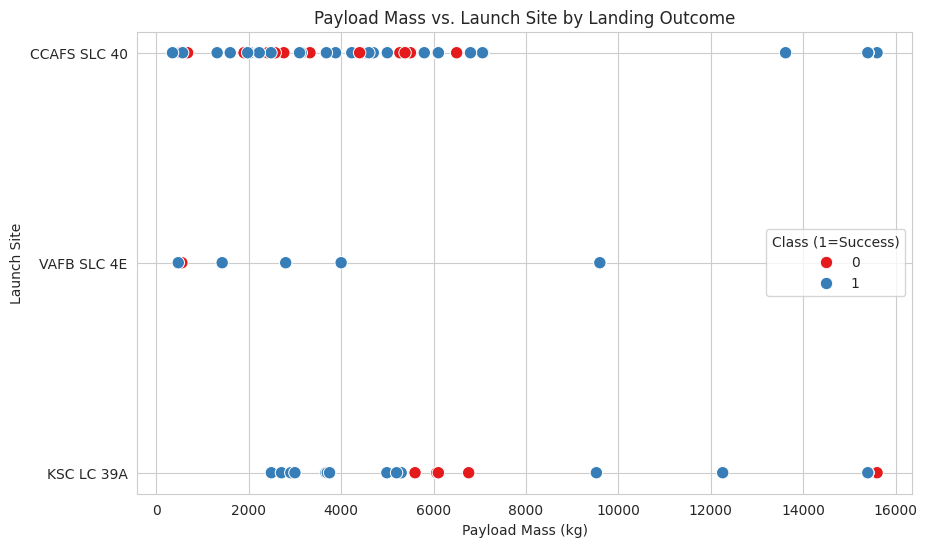

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class', palette='Set1', s=80)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs. Launch Site by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 4. Success rate by orbit type (bar chart)

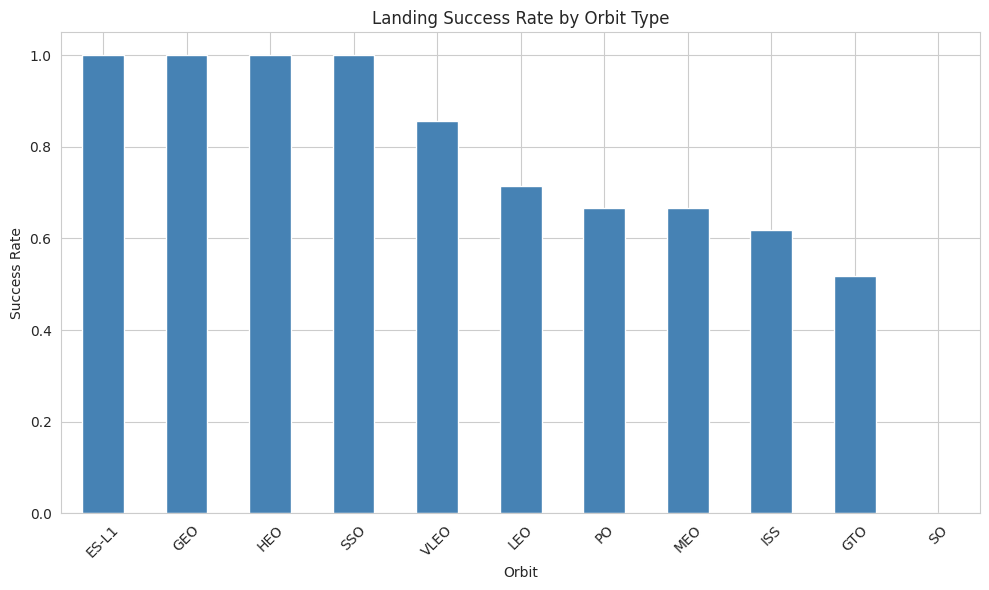

In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
orbit_success.plot(kind='bar', color='steelblue')
plt.xlabel('Orbit')
plt.ylabel('Success Rate')
plt.title('Landing Success Rate by Orbit Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Flight Number vs. Orbit

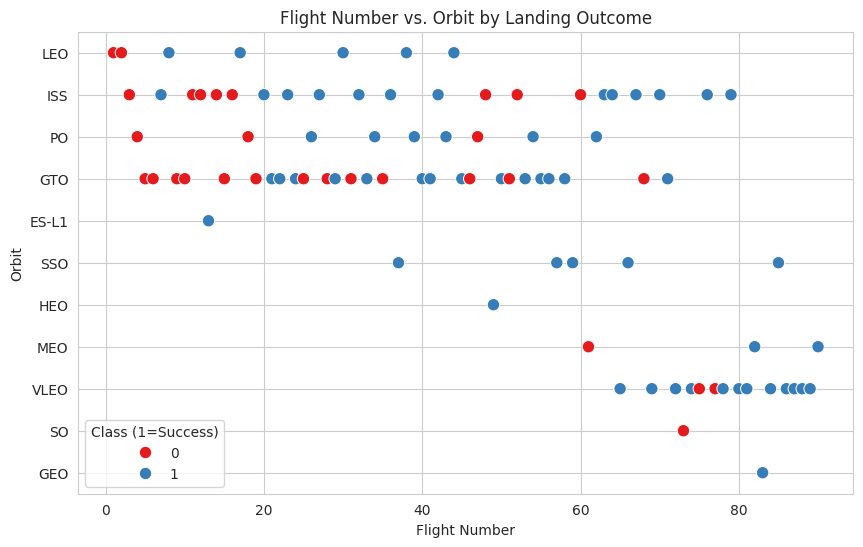

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Orbit')
plt.title('Flight Number vs. Orbit by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 6. Payload Mass vs. Orbit

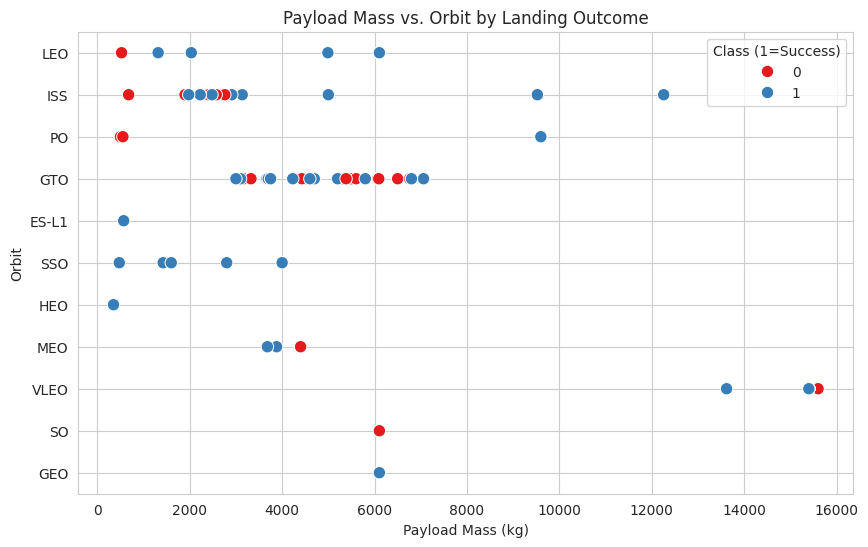

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', palette='Set1', s=80)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit')
plt.title('Payload Mass vs. Orbit by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 7. Yearly launch success trend
This is the key "yearly trends" chart required by the grading rubric.

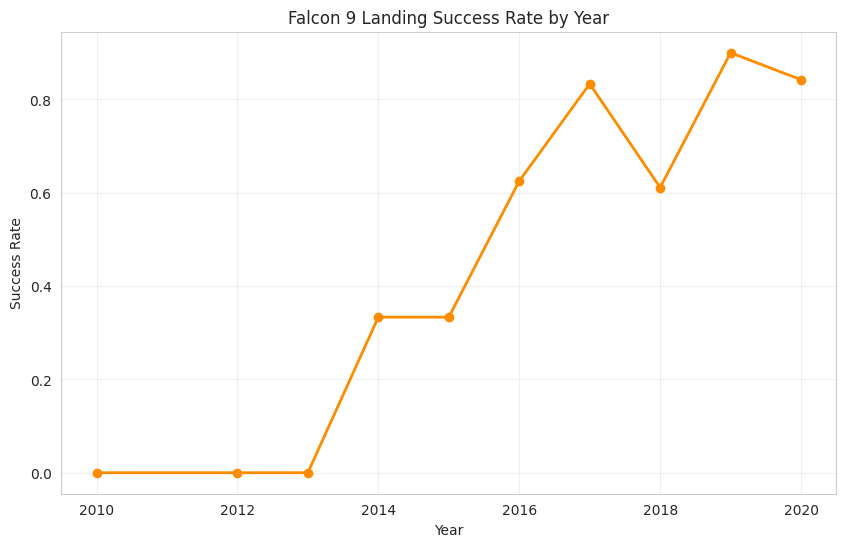

In [9]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
plt.plot(yearly_success.index, yearly_success.values, marker='o', linewidth=2, color='darkorange')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('Falcon 9 Landing Success Rate by Year')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Feature engineering: one-hot encode categorical columns
This produces the numeric feature matrix used later for machine learning (Lab 8).

In [10]:
features_to_encode = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
features_one_hot = pd.get_dummies(df[['FlightNumber', 'PayloadMass', 'Flights', 'GridFins',
                                        'Reused', 'Legs', 'Block', 'ReusedCount'] + features_to_encode],
                                   columns=features_to_encode)
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('Saved dataset_part_3.csv with', features_one_hot.shape[0], 'rows and', features_one_hot.shape[1], 'columns')

Saved dataset_part_3.csv with 90 rows and 80 columns
